In [1]:
# import libraries
import numpy as np
import sys
import matplotlib.pyplot as plt

1. 1D 2 cell Euler Equation test case
- test with uniform flow --> check eigenvalues and eigenvectors
- eigenvalues of dFdU (for boundary flux as well) should be u-c, u and u+c where c is the local speed of sound

Functions
- compute_dFdU_1d
- compute_dVdU_1d
- compute_dFdU_1d
- compute_roe_averaged_absolute_jacobian_1d

In [2]:
def compute_dFdU_1d(U, gamma=1.4):
    """
    Computes the 1D Euler flux Jacobian matrix dF/dU from conservative state vector U.
    U = [rho, rhou, rhoE]
    """
    rho  = U[0]
    rhou = U[1]
    rhoE = U[2]
    
    u = rhou / rho
    p = (gamma - 1.0) * (rhoE - 0.5 * rho * u**2)
    H = (rhoE + p) / rho
    u2 = u**2
    
    A = np.zeros((3, 3))
    A[0, 0] = 0.0
    A[0, 1] = 1.0
    A[0, 2] = 0.0
    
    A[1, 0] = (gamma - 3.0) * (u2 / 2.0)
    A[1, 1] = (3.0 - gamma) * u
    A[1, 2] = gamma - 1.0
    
    A[2, 0] = ((gamma - 1.0) / 2.0 * u2 - H) * u
    A[2, 1] = H + (1.0 - gamma) * u2
    A[2, 2] = gamma * u
    
    return A

In [3]:
gamma = 1.4
rho = 1.225        # density (kg/m^3)
u = 300.0          # velocity (m/s)
p = 101325.0       # pressure (Pa)

rhoE = p / (gamma - 1.0) + 0.5 * rho * u**2
rhou = rho * u

U = np.array([rho, rhou, rhoE])
# check A - 1D dFdU
A = compute_dFdU_1d(U, gamma)

# check with eigenstructure
# A = R * Lamda * L
# R = right eigenvectors matrix
# L =  left eigenvectors matrix
# Lamda = eigenvalue matrix

# define local speed of sound 
c = np.sqrt(gamma * p / rho)
print("Eigenvalues of A: ",np.linalg.eigvals(A))
print(f"Theorectical eigenvalues of A: {u-c}, {u}, {u+c}")





Eigenvalues of A:  [640.29399054 300.         -40.29399054]
Theorectical eigenvalues of A: -40.29399054347107, 300.0, 640.2939905434711


In [4]:
def compute_dVdU_1d_from_V(V, gamma=1.4):
    """
    Computes the transformation Jacobian matrix dV/dU using 
    primitive variables as the input vector.
    V = [rho, u, P]
    """
    rho = V[0]
    u   = V[1]
    
    dVdU = np.zeros((3, 3))
    
    # Row 0: d(rho)/dU
    dVdU[0, 0] = 1.0
    dVdU[0, 1] = 0.0
    dVdU[0, 2] = 0.0
    
    # Row 1: d(u)/dU
    dVdU[1, 0] = -u / rho
    dVdU[1, 1] = 1.0 / rho
    dVdU[1, 2] = 0.0
    
    # Row 2: d(P)/dU
    gm1 = gamma - 1.0
    dVdU[2, 0] = 0.5 * (u**2) * gm1
    dVdU[2, 1] = -u * gm1
    dVdU[2, 2] = gm1
    
    return dVdU


def compute_dFdV_1d_from_V(V, gamma=1.4):
    """
    Computes the flux Jacobian matrix dF/dV using 
    primitive variables as the input vector.
    V = [rho, u, P]
    """
    rho = V[0]
    u   = V[1]
    P   = V[2]
    
    # Kinetic energy per unit mass
    ek = 0.5 * u**2
    
    # Internal enthalpy: h = e + P/rho = c_p * T
    # Since e = P / (rho * (gamma - 1)), h = gamma * P / (rho * (gamma - 1))
    gm1 = gamma - 1.0
    h = (gamma * P) / (rho * gm1)
    
    # Total enthalpy: h_t = h + e_k
    ht = h + ek
    
    dFdV = np.zeros((3, 3))
    
    # Row 0
    dFdV[0, 0] = u
    dFdV[0, 1] = rho
    dFdV[0, 2] = 0.0
    
    # Row 1
    dFdV[1, 0] = u**2
    dFdV[1, 1] = 2.0 * rho * u
    dFdV[1, 2] = 1.0
    
    # Row 2
    dFdV[2, 0] = ht * u - (gamma * P * u) / (rho * gm1)
    dFdV[2, 1] = rho * (u**2 + ht)
    dFdV[2, 2] = (gamma / gm1) * u
    
    return dFdV


def compute_dFdU_boundary_1D_from_V(V, gamma=1.4):
    """
    Computes dFdU at the boundary via the chain rule: dFdV * dVdU
    Input: V = [rho, u, P]
    """
    dFdV = compute_dFdV_1d_from_V(V, gamma)
    dVdU = compute_dVdU_1d_from_V(V, gamma)
    
    # Matrix multiplication
    return np.dot(dFdV, dVdU)

In [5]:
# verify the boundary flux jaocbian by inputting primitive variables
# check the eigenvalue and right eigenvectors

rho_val = 1.225        # density
u_val   = 300.0        # velocity
p_val   = 101325.0     # pressure

# primitive variable
V_state = np.array([rho_val, u_val, p_val])

# Calculate derived parameters for theoretical comparison
c = np.sqrt(gamma * p_val / rho_val)
h = (gamma * p_val) / (rho_val * (gamma - 1.0))
ht = h + 0.5 * u_val**2

# 2. Compute Boundary Jacobian Matrix
A_boundary = compute_dFdU_boundary_1D_from_V(V_state, gamma)

# 3. Numerical Eigenvalues and Right Eigenvectors
# Note: np.linalg.eig returns columns as eigenvectors: e_vecs[:, i] corresponds to e_vals[i]
e_vals, e_vecs = np.linalg.eig(A_boundary)

# Sort eigenvalues and matching eigenvectors for structured comparison
sort_idx = np.argsort(e_vals)
e_vals = e_vals[sort_idx]
e_vecs = e_vecs[:, sort_idx]

# 4. Analytical (Theoretical) Right Eigenvectors for dFdU
# Corresponding to eigenvalues: [u-c, u, u+c]
R_theoretical = np.array([
    [1.0,           1.0,       1.0],
    [u_val - c,     u_val,     u_val + c],
    [ht - u_val*c,  0.5*u_val**2, ht + u_val*c]
])

print("Eigenvalues of boundary flux jacobian: ",e_vals)
print(f"Theorectical eigenvalues of A: {u_val-c}, {u_val}, {u_val+c}")

Eigenvalues of boundary flux jacobian:  [-40.29399054 300.         640.29399054]
Theorectical eigenvalues of A: -40.29399054347107, 300.0, 640.2939905434711


In [6]:
def compute_roe_averaged_absolute_jacobian_1d(UL, UR, gamma=1.4):
    """
    Computes the 1D Roe-averaged absolute flux Jacobian matrix from reference text:
    |A_tilde| = L_tilde * |lambda_tilde| * R_tilde
    
    Using: nx = 1, ny = 0 -> un = u, ut = 0
    """
    rhoL, rhouL, rhoEL = UL[0], UL[1], UL[2]
    rhoR, rhouR, rhoER = UR[0], UR[1], UR[2]
    
    beta = gamma - 1.0 #
    
    uL = rhouL / rhoL
    uR = rhouR / rhoR
    
    pL = beta * (rhoEL - 0.5 * rhoL * uL**2)
    pR = beta * (rhoER - 0.5 * rhoR * uR**2)
    
    htL = (rhoEL + pL) / rhoL
    htR = (rhoER + pR) / rhoR
    
    # Roe averages
    roe_w = np.sqrt(rhoR / rhoL)
    denom = 1.0 + roe_w
    
    u_tilde  = (uL + roe_w * uR) / denom #
    ht_tilde = (htL + roe_w * htR) / denom #
    
    Q_tilde = 0.5 * u_tilde**2 #
    C_tilde = np.sqrt(beta * (ht_tilde - Q_tilde)) #
    
    # --- 1. L_tilde Matrix (Eq. 4.14) ---
    # Dropping row 3 (v-momentum) and column 2 (shear wave)
    L_tilde = np.zeros((3, 3))
    
    # Column 0 (lambda = u)
    L_tilde[0, 0] = 1.0
    L_tilde[1, 0] = u_tilde
    L_tilde[2, 0] = Q_tilde
    
    # Column 1 (lambda = u + C)
    L_tilde[0, 1] = 1.0 / C_tilde**2
    L_tilde[1, 1] = (u_tilde / C_tilde**2) + (1.0 / C_tilde)
    L_tilde[2, 1] = (1.0 / beta) + (u_tilde / C_tilde) + (Q_tilde / C_tilde**2)
    
    # Column 2 (lambda = u - C)
    L_tilde[0, 2] = 1.0 / C_tilde**2
    L_tilde[1, 2] = (u_tilde / C_tilde**2) - (1.0 / C_tilde)
    L_tilde[2, 2] = (1.0 / beta) - (u_tilde / C_tilde) + (Q_tilde / C_tilde**2)
    
    # --- 2. |lambda| Matrix (Eq. 4.15) ---
    abs_lam = np.zeros((3, 3))
    abs_lam[0, 0] = np.abs(u_tilde)
    abs_lam[1, 1] = np.abs(u_tilde + C_tilde)
    abs_lam[2, 2] = np.abs(u_tilde - C_tilde)
    
    # --- 3. R_tilde Matrix (Eq. 4.16) ---
    # Dropping row 2 (shear wave) and column 2 (v-momentum)
    R_tilde = np.zeros((3, 3))
    
    # Row 0
    R_tilde[0, 0] = 1.0 - beta * Q_tilde / C_tilde**2
    R_tilde[0, 1] = beta * u_tilde / C_tilde**2
    R_tilde[0, 2] = -beta / C_tilde**2
    
    # Row 1
    R_tilde[1, 0] = 0.5 * (-C_tilde * u_tilde + beta * Q_tilde)
    R_tilde[1, 1] = 0.5 * (C_tilde - beta * u_tilde)
    R_tilde[1, 2] = 0.5 * beta
    
    # Row 2
    R_tilde[2, 0] = 0.5 * (C_tilde * u_tilde + beta * Q_tilde)
    R_tilde[2, 1] = 0.5 * (-C_tilde - beta * u_tilde)
    R_tilde[2, 2] = 0.5 * beta 

    # Reconstruct absolute flux Jacobian matrix: |A| = L * |λ| * R
    return np.dot(L_tilde, np.dot(abs_lam, R_tilde)), u_tilde, C_tilde


In [7]:
# verify tidle_A aboslute roe-averaged jacobian

# --- State A (Reference High Speed) ---
rhoA, uA, pA = 1.225, 300.0, 101325.0
UA = np.array([rhoA, rhoA*uA, pA/(gamma-1.0) + 0.5*rhoA*uA**2])

# --- State B (Different Density & Pressure) ---
rhoB, uB, pB = 0.5, 150.0, 50000.0
UB = np.array([rhoB, rhoB*uB, pB/(gamma-1.0) + 0.5*rhoB*uB**2])

# 1. Compute matrix and grab intermediate Roe speeds
abs_A_tilde, u_tilde, C_tilde = compute_roe_averaged_absolute_jacobian_1d(UA, UB)

# 2. Extract numerical eigenvalues from the constructed matrix
numerical_eigenvalues = np.sort(np.linalg.eigvals(abs_A_tilde))

# 3. Calculate exact theoretical absolute wave speeds
theoretical_eigenvalues = np.sort([
    np.abs(u_tilde), 
    np.abs(u_tilde + C_tilde), 
    np.abs(u_tilde - C_tilde)
])

print(f"  Roe-averaged velocity (u_tilde) : {u_tilde:.4f} m/s")
print(f"  Roe speed of sound (C_tilde)    : {C_tilde:.4f} m/s")
print(f"  Theoretical Absolute Waves      : {theoretical_eigenvalues}")
print(f"  Eigenvalues from matrix |A|     : {numerical_eigenvalues}")

  Roe-averaged velocity (u_tilde) : 241.5261 m/s
  Roe speed of sound (C_tilde)    : 355.3930 m/s
  Theoretical Absolute Waves      : [113.86686037 241.52611197 596.91908432]
  Eigenvalues from matrix |A|     : [113.86686037 241.52611197 596.91908432]


In [8]:
# Define physical conditions (Uniform flow state)
# Test case with uniform flow over 2 cells with prescribe boundary primitive vectors V

gamma = 1.4

rho_val = 1.225
u_val   = 300.0
p_val   = 101325.0

# local speed of sound
c_val = np.sqrt(gamma * p_val / rho_val)

# 1. Prescribe Boundary Primitive Vectors V
V_inlet  = np.array([rho_val, u_val, p_val])
V_outlet = np.array([rho_val, u_val, p_val])

# 2. Prescribe Cell Center Conservative Vectors U
rhoE_val = p_val / (gamma - 1.0) + 0.5 * rho_val * u_val**2
rhou_val = rho_val * u_val

U1 = np.array([rho_val, rhou_val, rhoE_val])
U2 = np.array([rho_val, rhou_val, rhoE_val])

# 3. unit normal vector (1D Grid metrics)
n1 = 1.0 # cell 1 - outward
n_inlet = - 1.0 # cell 1 - outward
n_outlet = 1.0 # cell 1 - outward

l1 = 1.0        # cell face area/length of cell 1
l_inlet = 1.0   # Inlet face area/length
l_outlet = 1.0  # Outlet face area/length

# 4. Compute Flux Jacobians across interior face (Roe flux)
abs_A_tidle = compute_roe_averaged_absolute_jacobian_1d(U1, U2, gamma)[0]

dFU1U2_dU1 = 0.5 * (compute_dFdU_1d(U1, gamma) + abs_A_tidle)
dFU1U2_dU2 = 0.5 * (compute_dFdU_1d(U2, gamma) - abs_A_tidle)

# 5. Compute Boundary dFdU 
dFdU_inlet  = compute_dFdU_boundary_1D_from_V(V_inlet, gamma)
dFdU_outlet = compute_dFdU_boundary_1D_from_V(V_outlet, gamma)

# 6. Assemble Block Matrices (with boundary conditions)
J11 = dFU1U2_dU1 * n1 * l1 + dFdU_inlet * n_inlet * l_inlet
J12 = dFU1U2_dU2 * n1 * l1

J21 = -dFU1U2_dU1 * n1 * l1  
J22 = -dFU1U2_dU2 * n1 * l1 + dFdU_outlet * n_outlet * l_outlet

# Assemble Block Matrices (without boundary conditions)

# J11 = dFU1U2_dU1 * n1 * l1 
# J12 = dFU1U2_dU2 * n1 * l1

# J21 = -dFU1U2_dU1 * n1 * l1
# J22 = -dFU1U2_dU2 * n1 * l1

# 7. Construct Global 6x6 Matrix System
Global_Jacobian = np.block([
    [J11, J12],
    [J21, J22]
])

global_eigenvalues = np.linalg.eigvals(Global_Jacobian)

# Sort by real parts for a clean display
global_eigenvalues_sorted = np.sort(global_eigenvalues)

# Exact expected local wave speeds
expected_speeds = np.array([u_val - c_val, u_val, u_val + c_val])

print("=========================================================")
print("       GLOBAL 6x6 SYSTEM EIGENVALUE VERIFICATION        ")
print("=========================================================\n")
print(f"Local Velocity (u)       : {u_val:.2f} m/s")
print(f"Local Speed of Sound (c) : {c_val:.2f} m/s")
print(f"Expected Wave Speeds     : {expected_speeds}\n")

print("--- Computed 6 Global System Eigenvalues ---")
for idx, eig in enumerate(global_eigenvalues_sorted):
    # Format printing complex numbers cleanly
    real_part = np.round(eig.real, 4)
    imag_part = np.round(eig.imag, 4)
    print(f"  λ_{idx}: {real_part} + {imag_part}j")

       GLOBAL 6x6 SYSTEM EIGENVALUE VERIFICATION        

Local Velocity (u)       : 300.00 m/s
Local Speed of Sound (c) : 340.29 m/s
Expected Wave Speeds     : [-40.29399054 300.         640.29399054]

--- Computed 6 Global System Eigenvalues ---
  λ_0: -0.0 + 0.0j
  λ_1: -0.0 + 0.0j
  λ_2: 0.0 + 0.0j
  λ_3: 40.294 + 0.0j
  λ_4: 300.0 + 0.0j
  λ_5: 640.294 + 0.0j


2. Verifications of the 1D Euler flux jacoabian with finite-difference method
- by forward difference, dFdU = (F(U+eps) - F(U))/eps
- optimal eps = 2 * sqrt(machine epsilon) Referenced from O. Onur and S. Eyi
- check each of the local flux jacobian matrix first

Functions
- euler_flux1_1d 
- compute_dFdU_fd_1d
- convert_V_to_U_1d
- compute_dFdU_boundary_fd_from_V

In [ ]:
# finite difference jacobian

def euler_flux_1d(U, gamma=1.4):
    """
    Computes the standard 1D Euler Flux vector F(U).
    U = [rho, rhou, rhoE]
    F = [rhou, rhou*u + P, (rhoE + P)*u]
    """
    rho  = U[0]
    rhou = U[1]
    rhoE = U[2]
    
    # Extract velocity and pressure
    u = rhou / rho
    P = (gamma - 1.0) * (rhoE - 0.5 * rho * u**2)
    
    # Construct flux vector
    F = np.zeros(3)
    F[0] = rhou
    F[1] = rhou * u + P
    F[2] = (rhoE + P) * u
    
    return F

# 2. FINITE DIFFERENCE FLUX JACOBIAN FUNCTION

def compute_dFdU_fd_1d(U, eps=1e-7, gamma=1.4):
    """
    Computes the 1D Euler Flux Jacobian (dFdU) using Forward Finite Differences.
    
    Parameters:
    -----------
    U     : ndarray of shape (3,) -> [rho, rhou, rhoE]
    eps   : float -> Perturbation step size
    gamma : float -> Ratio of specific heats
    
    Returns:
    --------
    dFdU  : ndarray of shape (3, 3) -> Numerical Jacobian matrix
    """
    # Initialize a clean 3x3 matrix
    dFdU = np.zeros((3, 3))
    
    # Generate the 3x3 base identity matrix for columns perturbations
    I = np.eye(3)
    
    # Compute base flux at unperturbed state: F(U)
    F_base = euler_flux_1d(U, gamma)
    
    # Loop over each equation variable (col 0=rho, col 1=rhou, col 2=rhoE)
    for j in range(3):
        # Apply perturbation step along the j-th component direction
        Up = U + eps * I[:, j]
        
        # Calculate perturbed flux: F(Up)
        F_perturbed = euler_flux_1d(Up, gamma)
        
        # Approximate the derivative for the j-th column of the Jacobian
        dFdU[:, j] = (F_perturbed - F_base) / eps
        
    return dFdU

# verification with analytical jacobian

gamma_test = 1.4
rho_test   = 1.225
u_test     = 300.0
p_test     = 101325.0

rhoE_test = p_test / (gamma_test - 1.0) + 0.5 * rho_test * u_test**2
rhou_test = rho_test * u_test
U_state   = np.array([rho_test, rhou_test, rhoE_test])

# Run finite difference Jacobian
machine_eps = sys.float_info.epsilon
epsilon = 2 * np.sqrt(machine_eps)

dFdU_numerical = compute_dFdU_fd_1d(U_state, eps=epsilon, gamma=gamma_test)
dFdU_analytical = compute_dFdU_1d(U_state)

matrix_error = np.linalg.norm(dFdU_analytical  - dFdU_numerical)

print("=========================================================")
print("      1D EULER FLUX FINITE DIFFERENCE JACOBIAN           ")
print("=========================================================\n")
print(f"Perturbation step size (eps): {epsilon}")
print("\n--- Resulting 3x3 Numerical Flux Jacobian Matrix ---")
print(np.round(dFdU_numerical, 5))
print("\n--- Resulting 3x3 Analytical Flux Jacobian Matrix ---")
print(np.round(dFdU_analytical, 5))
print(f"L2 norm  : {matrix_error:.2e}")

      1D EULER FLUX FINITE DIFFERENCE JACOBIAN           

Perturbation step size (eps): 2.9802322387695312e-08

--- Resulting 3x3 Numerical Flux Jacobian Matrix ---
[[ 0.00000000e+00  1.00000000e+00  0.00000000e+00]
 [-7.19999980e+04  4.80000000e+02  4.00390000e-01]
 [-9.49499975e+07  2.98500000e+05  4.20000000e+02]]

--- Resulting 3x3 Analytical Flux Jacobian Matrix ---
[[ 0.000e+00  1.000e+00  0.000e+00]
 [-7.200e+04  4.800e+02  4.000e-01]
 [-9.495e+07  2.985e+05  4.200e+02]]
L2 norm  : 2.50e+00


3.1 1D Boundary Euler Flux jacobian

Verifications of the 1D Boundary Euler flux jacoabian with finite-difference method
- by forward difference, dFdU = (F(U+eps) - F(U))/eps
- a difference flux function --> take primitive variable vector V as input

In [10]:
def convert_V_to_U_1d(V, gamma=1.4):
    """Converts primitive vector V = [rho, u, P] to conservative U."""
    rho, u, P = V[0], V[1], V[2]
    rhou = rho * u
    rhoE = P / (gamma - 1.0) + 0.5 * rho * u**2
    return np.array([rho, rhou, rhoE])

def euler_flux_1d(U, gamma=1.4):
    """Computes standard 1D Euler Flux vector F(U)."""
    rho, rhou, rhoE = U[0], U[1], U[2]
    u = rhou / rho
    P = (gamma - 1.0) * (rhoE - 0.5 * rho * u**2)
    
    F = np.zeros(3)
    F[0] = rhou
    F[1] = rhou * u + P
    F[2] = (rhoE + P) * u
    return F

# =============================================================================
# FINITE DIFFERENCE BOUNDARY JACOBIAN 
# =============================================================================

def compute_dFdU_boundary_fd_from_V(V, eps=1e-7, gamma=1.4):
    """
    Computes the 1D boundary flux Jacobian (dFdU) via finite differences.
    Takes primitive vector V as direct input, converts to conservative vector U,
    perturbs U, and calculates the resulting flux variations.
    """
    # 1. Convert primitive state V to conservative state U
    U = convert_V_to_U_1d(V, gamma)
    
    # Initialize a clean 3x3 matrix for dFdU
    dFdU_boundary = np.zeros((3, 3))
    I = np.eye(3)
    
    # Base flux evaluated at the unperturbed conservative state: flux(U)
    F_base = euler_flux_1d(U, gamma)
    
    # 2. Loop over conservative components to perturb column-by-column
    for j in range(3):
        # Up = U + eps * identity_matrix_column
        Up = U + eps * I[:, j]
        
        # Calculate perturbed flux: flux(Up)
        F_perturbed = euler_flux_1d(Up, gamma)
        
        # 3. Boundary flux Jacobian column calculation
        dFdU_boundary[:, j] = (F_perturbed - F_base) / eps
        
    return dFdU_boundary

gamma_test = 1.4
V_test = np.array([1.225, 300.0, 101325.0]) # [rho, u, P]

# define eps
machine_eps = sys.float_info.epsilon
epsilon = 2 * np.sqrt(machine_eps)

# Run the numerical finite difference boundary jacobian
dFdU_boundary_num = compute_dFdU_boundary_fd_from_V(V_test, eps=epsilon, gamma=gamma_test)
dFdU_boundary_analytical = compute_dFdU_boundary_1D_from_V(V_test, gamma = gamma_test)

print("=========================================================")
print("  1D BOUNDARY FLUX JACOBIAN VIA CONSERVATIVE FD STEP    ")
print("=========================================================\n")
print("--- Resulting 3x3 Boundary Flux Jacobian Matrix (dFdU) by FD ---")
print(np.round(dFdU_boundary_num, 5))
print("--- Resulting 3x3 Boundary Flux Jacobian Matrix (dFdU) , analytical---")
print(np.round(dFdU_boundary_analytical, 5))

  1D BOUNDARY FLUX JACOBIAN VIA CONSERVATIVE FD STEP    

--- Resulting 3x3 Boundary Flux Jacobian Matrix (dFdU) by FD ---
[[ 0.00000000e+00  1.00000000e+00  0.00000000e+00]
 [-7.19999980e+04  4.80000000e+02  4.00390000e-01]
 [-9.49499975e+07  2.98500000e+05  4.20000000e+02]]
--- Resulting 3x3 Boundary Flux Jacobian Matrix (dFdU) , analytical---
[[ 0.000e+00  1.000e+00  0.000e+00]
 [-7.200e+04  4.800e+02  4.000e-01]
 [-9.495e+07  2.985e+05  4.200e+02]]


3.2 1D Boundary Wall flux jacobian
- set normal flux to zero for boundary wall flux

In [11]:
# define dFdU_wall - analytical method

def compute_dFdU_wall_1D_from_V(V, gamma=1.4):
    """
    Computes dFdU at the boundary via the chain rule: dFdV * dVdU
    Input: V = [rho, u, P]
    """
    dFdV_wall = np.zeros((3,3))
    dFdV_wall[1, 2] = 1.0
    dVdU = compute_dVdU_1d_from_V(V, gamma)
    
    # Matrix multiplication
    return np.dot(dFdV_wall, dVdU)


# define dFdU_wall - finite difference method

def wall_flux_1d(U, gamma=1.4):
    """Computes standard 1D Euler Flux vector F(U)."""
    rho, rhou, rhoE = U[0], U[1], U[2]
    u = rhou / rho
    P = (gamma - 1.0) * (rhoE - 0.5 * rho * u**2)
    
    F = np.zeros(3)
    F[0] = 0
    F[1] = P
    F[2] = 0
    return F

# =============================================================================
# FINITE DIFFERENCE BOUNDARY JACOBIAN 
# =============================================================================

def compute_dFdU_wall_fd_from_V(V, eps=1e-7, gamma=1.4):
    """
    Computes the 1D boundary flux Jacobian (dFdU) via finite differences.
    Takes primitive vector V as direct input, converts to conservative vector U,
    perturbs U, and calculates the resulting flux variations.
    """
    # 1. Convert primitive state V to conservative state U
    U = convert_V_to_U_1d(V, gamma)
    
    # Initialize a clean 3x3 matrix for dFdU
    dFdU_wall = np.zeros((3, 3))
    I = np.eye(3)
    
    # Base flux evaluated at the unperturbed conservative state: flux(U)
    F_base = wall_flux_1d(U, gamma)
    
    # 2. Loop over conservative components to perturb column-by-column
    for j in range(3):
        # Up = U + eps * identity_matrix_column
        Up = U + eps * I[:, j]
        
        # Calculate perturbed flux: flux(Up)
        F_perturbed = wall_flux_1d(Up, gamma)   
        
        # 3. Boundary flux Jacobian column calculation
        dFdU_wall[:, j] = (F_perturbed - F_base) / eps
        
    return dFdU_wall

# test

gamma_test = 1.4
V_test_wall = np.array([1.225, 0, 101325.0]) # [rho, u, P] # set wall flux un = u *nx = 0 for 1D case
U_test_wall = convert_V_to_U_1d(V_test_wall)

# define eps
machine_eps = sys.float_info.epsilon
epsilon = 2 * np.sqrt(machine_eps)


compute_dFdV_1d_from_V(U_test_wall)
euler_flux_1d(U_test_wall)


# Run the numerical finite difference boundary jacobian
dFdU__wall_num = compute_dFdU_wall_fd_from_V(V_test_wall, eps=epsilon, gamma=gamma_test)
dFdU__wall_analytical = compute_dFdU_wall_1D_from_V(V_test_wall, gamma = gamma_test)

print("=========================================================")
print("  1D BOUNDARY WALL FLUX JACOBIAN VIA CONSERVATIVE FD STEP    ")
print("=========================================================\n")
print("--- Resulting 3x3 Boundary Wall Flux Jacobian Matrix (dFdU) by FD ---")
print(np.round(dFdU__wall_num, 5))
print("--- Resulting 3x3 Boundary Wall Flux Jacobian Matrix (dFdU) , analytical---")
print(np.round(dFdU__wall_analytical, 5))


  1D BOUNDARY WALL FLUX JACOBIAN VIA CONSERVATIVE FD STEP    

--- Resulting 3x3 Boundary Wall Flux Jacobian Matrix (dFdU) by FD ---
[[0.     0.     0.    ]
 [0.     0.     0.3999]
 [0.     0.     0.    ]]
--- Resulting 3x3 Boundary Wall Flux Jacobian Matrix (dFdU) , analytical---
[[0.  0.  0. ]
 [0.  0.  0.4]
 [0.  0.  0. ]]


4. Verification of the global flux jacobian with FD

In [12]:
gamma = 1.4

# define finite difference pertubutation eps
machine_eps = sys.float_info.epsilon
# eps_fd = 2 * np.sqrt(machine_eps)
eps_fd = 1.6298e-08

# Define physical primitive variables
rho_val, u_val, p_val = 1.225, 300.0, 101325.0

V_inlet  = np.array([rho_val, u_val, p_val])
V_outlet = np.array([rho_val, u_val, p_val])

U1 = convert_V_to_U_1d(V_inlet, gamma)
U2 = convert_V_to_U_1d(V_outlet, gamma)

# 1D Metrics and Sign Orientation
n1, n_inlet, n_outlet = 1.0, -1.0, 1.0
l1, l_inlet, l_outlet = 1.0, 1.0, 1.0

# -------------------------------------------------------------------------
# ASSEMBLY PATH A: ANALYTICAL METHOD
# -------------------------------------------------------------------------
abs_A_analytical = compute_roe_averaged_absolute_jacobian_1d(U1, U2, gamma)[0]

dFdU1_ana = 0.5 * (compute_dFdU_1d(U1, gamma) + abs_A_analytical)
dFdU2_ana = 0.5 * (compute_dFdU_1d(U2, gamma) - abs_A_analytical)

dFdU_inlet_ana  = compute_dFdU_boundary_1D_from_V(V_inlet, gamma)
dFdU_outlet_ana = compute_dFdU_boundary_1D_from_V(V_outlet, gamma)

# Construct blocks
J11_ana = dFdU1_ana * n1 * l1 + dFdU_inlet_ana * n_inlet * l_inlet
J12_ana = dFdU2_ana * n1 * l1
J21_ana = -dFdU1_ana * n1 * l1
J22_ana = -dFdU2_ana * n1 * l1 + dFdU_outlet_ana * n_outlet * l_outlet

Global_Jacobian_Analytical = np.block([[J11_ana, J12_ana], [J21_ana, J22_ana]])

# -------------------------------------------------------------------------
# ASSEMBLY PATH B: FINITE DIFFERENCE METHOD
# -------------------------------------------------------------------------
# Note: The Roe numerical flux linearization is preserved analytically while 
# flux components use numerical forward derivative approximations.
dFdU1_fd = 0.5 * (compute_dFdU_fd_1d(U1, eps_fd, gamma) + abs_A_analytical)
dFdU2_fd = 0.5 * (compute_dFdU_fd_1d(U2, eps_fd, gamma) - abs_A_analytical)

dFdU_inlet_fd  = compute_dFdU_boundary_fd_from_V(V_inlet, eps_fd, gamma)
dFdU_outlet_fd = compute_dFdU_boundary_fd_from_V(V_outlet, eps_fd, gamma)

# Construct blocks
J11_fd = dFdU1_fd * n1 * l1 + dFdU_inlet_fd * n_inlet * l_inlet
J12_fd = dFdU2_fd * n1 * l1
J21_fd = -dFdU1_fd * n1 * l1
J22_fd = -dFdU2_fd * n1 * l1 + dFdU_outlet_fd * n_outlet * l_outlet

Global_Jacobian_Numerical = np.block([[J11_fd, J12_fd], [J21_fd, J22_fd]])

# -------------------------------------------------------------------------
# COMPARE SYSTEMS
# -------------------------------------------------------------------------
# Calculate matrix difference Norm
matrix_error = np.linalg.norm(Global_Jacobian_Analytical - Global_Jacobian_Numerical)
max_abs_diff = np.max(np.abs(Global_Jacobian_Analytical - Global_Jacobian_Numerical))

print("=========================================================")
print("      GLOBAL 6x6 JACOBIAN VERIFICATION ANALYSIS          ")
print("=========================================================\n")
print("--- 1. ANALYTICAL GLOBAL JACOBIAN SYSTEM MATRIX ---")
print(Global_Jacobian_Analytical)
print("\n" + "-"*80 + "\n")

print("--- 2. FINITE-DIFFERENCE GLOBAL JACOBIAN SYSTEM MATRIX ---")
print(Global_Jacobian_Numerical)
print("\n" + "-"*80 + "\n")
print(f"L2 norm  : {matrix_error:.2e}")
print(f"L1 norm  : {max_abs_diff:.2e}")

      GLOBAL 6x6 JACOBIAN VERIFICATION ANALYSIS          

--- 1. ANALYTICAL GLOBAL JACOBIAN SYSTEM MATRIX ---
[[ 2.08930599e+01 -8.00823908e-02  6.95923844e-05 -2.08930599e+01
   8.00823908e-02 -6.95923844e-05]
 [-8.41864759e+02  3.22683910e+00 -2.80415488e-03  8.41864759e+02
  -3.22683910e+00  2.80415488e-03]
 [ 4.85579373e+06 -1.86120928e+04  1.61740915e+01 -4.85579373e+06
   1.86120928e+04 -1.61740915e+01]
 [-2.08930599e+01 -9.19917609e-01 -6.95923844e-05  2.08930599e+01
   9.19917609e-01  6.95923844e-05]
 [ 7.28418648e+04 -4.83226839e+02 -3.97195845e-01 -7.28418648e+04
   4.83226839e+02  3.97195845e-01]
 [ 9.00942063e+07 -2.79887907e+05 -4.36174092e+02 -9.00942063e+07
   2.79887907e+05  4.36174092e+02]]

--------------------------------------------------------------------------------

--- 2. FINITE-DIFFERENCE GLOBAL JACOBIAN SYSTEM MATRIX ---
[[ 2.08930599e+01 -8.00816092e-02  6.95923844e-05 -2.08930599e+01
   8.00816092e-02 -6.95923844e-05]
 [-8.41864890e+02  3.22738164e+00 -2.80

5. Finding the optimal eps by sweeping eps and plot the L1 and L2 error from global-jacobian-numerical - global-jacobian-analytical
- it is only for euler flux for now
- it could be implemented to NS equation /2D/3D case to find the optimal eps for future code

           OPTIMAL PERTURBATION OPTIMIZATION             

Optimal identified step-size (eps) : 1.6298e-08
Minimum L2 Frobenius divergence    : 9.8651e-01


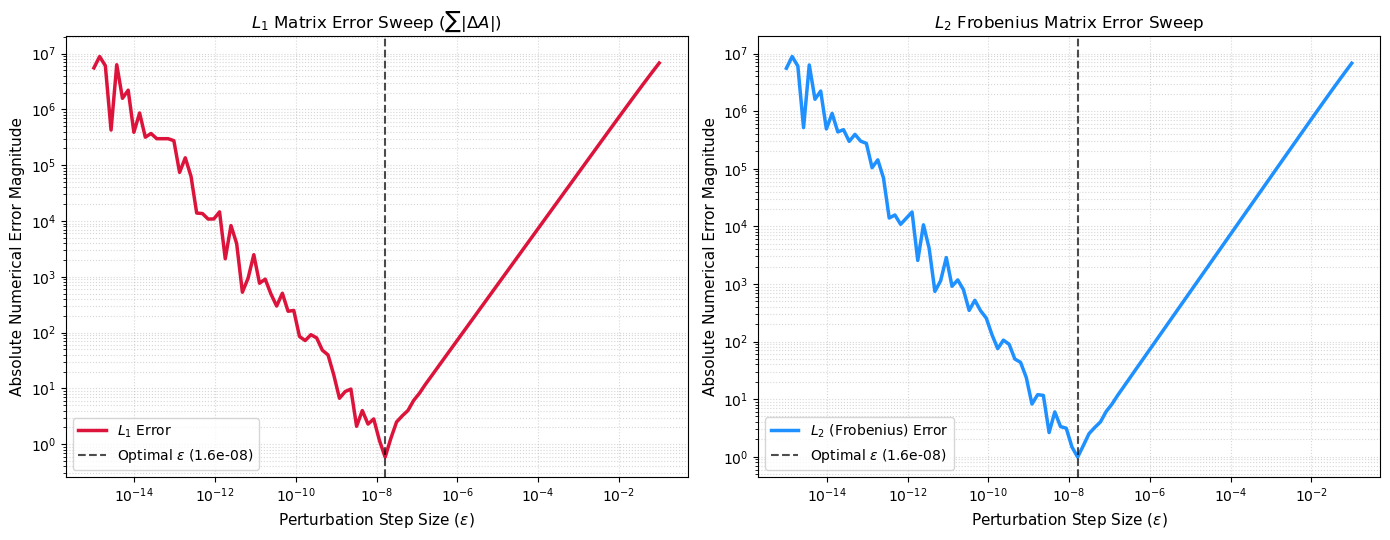

In [13]:
gamma = 1.4

# Static flow variables for base state
rho_val, u_val, p_val = 1.225, 300.0, 101325.0
V_inlet  = np.array([rho_val, u_val, p_val])
V_outlet = np.array([rho_val, u_val, p_val])
U1 = convert_V_to_U_1d(V_inlet, gamma)
U2 = convert_V_to_U_1d(V_outlet, gamma)

n1, n_inlet, n_outlet = 1.0, -1.0, 1.0
l1, l_inlet, l_outlet = 1.0, 1.0, 1.0

# Reconstruct pure Reference Analytical Global Matrix
abs_A_analytical = compute_roe_averaged_absolute_jacobian_1d(U1, U2, gamma)[0]
dFdU1_ana = 0.5 * (compute_dFdU_1d(U1, gamma) + abs_A_analytical)
dFdU2_ana = 0.5 * (compute_dFdU_1d(U2, gamma) - abs_A_analytical)
dFdU_inlet_ana  = compute_dFdU_boundary_1D_from_V(V_inlet, gamma)
dFdU_outlet_ana = compute_dFdU_boundary_1D_from_V(V_outlet, gamma)

J11_ana = dFdU1_ana * n1 * l1 + dFdU_inlet_ana * n_inlet * l_inlet
J12_ana = dFdU2_ana * n1 * l1
J21_ana = -dFdU1_ana * n1 * l1
J22_ana = -dFdU2_ana * n1 * l1 + dFdU_outlet_ana * n_outlet * l_outlet
Global_A_ana = np.block([[J11_ana, J12_ana], [J21_ana, J22_ana]])

# Generate broad logarithmic sweep array for eps: 10^-15 to 10^-1
eps_values = np.logspace(-15, -1, 100)
l1_errors = []
l2_errors = []

for eps in eps_values:
    # Build Finite Difference version
    dFdU1_fd = 0.5 * (compute_dFdU_fd_1d(U1, eps, gamma) + abs_A_analytical)
    dFdU2_fd = 0.5 * (compute_dFdU_fd_1d(U2, eps, gamma) - abs_A_analytical)
    dFdU_inlet_fd  = compute_dFdU_boundary_fd_from_V(V_inlet, eps, gamma)
    dFdU_outlet_fd = compute_dFdU_boundary_fd_from_V(V_outlet, eps, gamma)
    
    J11_fd = dFdU1_fd * n1 * l1 + dFdU_inlet_fd * n_inlet * l_inlet
    J12_fd = dFdU2_fd * n1 * l1
    J21_fd = -dFdU1_fd * n1 * l1
    J22_fd = -dFdU2_fd * n1 * l1 + dFdU_outlet_fd * n_outlet * l_outlet
    Global_A_fd = np.block([[J11_fd, J12_fd], [J21_fd, J22_fd]])
    
    # Matrix difference properties
    delta = Global_A_ana - Global_A_fd
    
    # Calculate L1 matrix norm (Max absolute column sum)
    l1_err = np.linalg.norm(delta, ord=1)
    # Calculate L2 matrix norm (Frobenius norm/spectral metric)
    l2_err = np.linalg.norm(delta, ord='fro')
    
    l1_errors.append(l1_err)
    l2_errors.append(l2_err)
        
# Find minimums index
opt_idx_l2 = np.argmin(l2_errors)
opt_eps = eps_values[opt_idx_l2]

print("=========================================================")
print("           OPTIMAL PERTURBATION OPTIMIZATION             ")
print("=========================================================\n")
print(f"Optimal identified step-size (eps) : {opt_eps:.4e}")
print(f"Minimum L2 Frobenius divergence    : {l2_errors[opt_idx_l2]:.4e}")

# -------------------------------------------------------------------------
# PLOT MULTI-PANEL DIAGRAM GRAPH
# -------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Panel 1: L1 Error Curve
ax1.loglog(eps_values, l1_errors, color='crimson', lw=2.5, label=r'$L_1$ Error')
ax1.axvline(opt_eps, color='black', linestyle='--', alpha=0.7, label=f'Optimal $\epsilon$ ({opt_eps:.1e})')
ax1.set_title(r'$L_1$ Matrix Error Sweep ($\sum | \Delta A |$)', fontsize=12)
ax1.set_xlabel(r'Perturbation Step Size ($\epsilon$)', fontsize=11)
ax1.set_ylabel('Absolute Numerical Error Magnitude', fontsize=11)
ax1.grid(True, which="both", ls=":", alpha=0.5)
ax1.legend(fontsize=10)

# Panel 2: L2 Error Curve
ax2.loglog(eps_values, l2_errors, color='dodgerblue', lw=2.5, label=r'$L_2$ (Frobenius) Error')
ax2.axvline(opt_eps, color='black', linestyle='--', alpha=0.7, label=f'Optimal $\epsilon$ ({opt_eps:.1e})')
ax2.set_title(r'$L_2$ Frobenius Matrix Error Sweep', fontsize=12)
ax2.set_xlabel(r'Perturbation Step Size ($\epsilon$)', fontsize=11)
ax2.set_ylabel('Absolute Numerical Error Magnitude', fontsize=11)
ax2.grid(True, which="both", ls=":", alpha=0.5)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

6. 1D Euler equation 3 cell case
- verify with eigenvalues

In [14]:
# Define physical conditions (Uniform flow state)
# Test case with uniform flow over 2 cells with prescribe boundary primitive vectors V

gamma = 1.4

rho_val = 1.225
u_val   = 300.0
p_val   = 101325.0

# local speed of sound
c_val = np.sqrt(gamma * p_val / rho_val)

# 1. Prescribe Boundary Primitive Vectors V
V_inlet  = np.array([rho_val, u_val, p_val])
V_outlet = np.array([rho_val, u_val, p_val])

# 2. Prescribe Cell Center Conservative Vectors U
rhoE_val = p_val / (gamma - 1.0) + 0.5 * rho_val * u_val**2
rhou_val = rho_val * u_val

U1 = np.array([rho_val, rhou_val, rhoE_val])
U2 = np.array([rho_val, rhou_val, rhoE_val])
U3 = np.array([rho_val, rhou_val, rhoE_val])

# 3. unit normal vector (1D Grid metrics)
n1 = 1.0 # cell 1 - outward
n_inlet = - 1.0 # cell 1 - outward
n_outlet = 1.0 # cell 1 - outward

l1 = 1.0        # cell face area/length of cell 1
l_inlet = 1.0   # Inlet face area/length
l_outlet = 1.0  # Outlet face area/length

n2 = 1 # cell 2 - outward
l2 = 1 # cell face area/length of cell 2

# 4. Compute Flux Jacobians across interior face (Roe flux)
abs_A_tidle_U1U2 = compute_roe_averaged_absolute_jacobian_1d(U1, U2, gamma)[0]
abs_A_tidle_U2U3 = compute_roe_averaged_absolute_jacobian_1d(U2, U3, gamma)[0]

dFU1U2_dU1 = 0.5 * (compute_dFdU_1d(U1, gamma) + abs_A_tidle_U1U2)
dFU1U2_dU2 = 0.5 * (compute_dFdU_1d(U2, gamma) - abs_A_tidle_U1U2)

dFU2U3_dU2 = 0.5 * (compute_dFdU_1d(U2, gamma) + abs_A_tidle_U2U3)
dFU2U3_dU3 = 0.5 * (compute_dFdU_1d(U2, gamma) - abs_A_tidle_U2U3)

# 5. Compute Boundary dFdU 
dFdU_inlet  = compute_dFdU_boundary_1D_from_V(V_inlet, gamma)
dFdU_outlet = compute_dFdU_boundary_1D_from_V(V_outlet, gamma)

# 6. Assemble Block Matrices (with boundary conditions)

# for cell 1
J11 = dFU1U2_dU1 * n1 * l1 + dFdU_inlet * n_inlet * l_inlet
J12 = dFU1U2_dU2 * n1 * l1
J13 = np.zeros([3,3])

# for cell 2
J22 = -dFU1U2_dU2 * n1 * l1 + dFU2U3_dU2 * n2 * l2
J21 = -dFU1U2_dU1 * n1 * l1  
J23 = dFU2U3_dU3 * n2 * l2

# for cell 3
J33 = - dFU2U3_dU3 * n2 * l2 + dFdU_outlet * n_outlet * l_outlet

J32 = - dFU2U3_dU2 * n2 * l2
J31 = np.zeros([3,3])


# Assemble Block Matrices (without boundary conditions)

# J11 = dFU1U2_dU1 * n1 * l1 
# J12 = dFU1U2_dU2 * n1 * l1

# J21 = -dFU1U2_dU1 * n1 * l1
# J22 = -dFU1U2_dU2 * n1 * l1

# 7. Construct Global 6x6 Matrix System
Global_Jacobian = np.block([
    [J11, J12, J13],
    [J21, J22, J23],
    [J31, J32, J33]
])

global_eigenvalues = np.linalg.eigvals(Global_Jacobian)

# Sort by real parts for a clean display
global_eigenvalues_sorted = np.sort(global_eigenvalues)

# Exact expected local wave speeds
expected_speeds = np.array([u_val - c_val, u_val, u_val + c_val])

print("=========================================================")
print("       GLOBAL 9x9 SYSTEM EIGENVALUE VERIFICATION        ")
print("=========================================================\n")
print(f"Local Velocity (u)       : {u_val:.2f} m/s")
print(f"Local Speed of Sound (c) : {c_val:.2f} m/s")
print(f"Expected Wave Speeds     : {expected_speeds}\n")

print("--- Computed 6 Global System Eigenvalues ---")
for idx, eig in enumerate(global_eigenvalues_sorted):
    # Format printing complex numbers cleanly
    real_part = np.round(eig.real, 4)
    imag_part = np.round(eig.imag, 4)
    print(f"  λ_{idx}: {real_part} + {imag_part}j")

       GLOBAL 9x9 SYSTEM EIGENVALUE VERIFICATION        

Local Velocity (u)       : 300.00 m/s
Local Speed of Sound (c) : 340.29 m/s
Expected Wave Speeds     : [-40.29399054 300.         640.29399054]

--- Computed 6 Global System Eigenvalues ---
  λ_0: -0.0 + 0.0j
  λ_1: 0.0 + -0.0j
  λ_2: 0.0 + 0.0j
  λ_3: 40.294 + 0.0j
  λ_4: 40.294 + 0.0j
  λ_5: 300.0 + -0.0j
  λ_6: 300.0 + 0.0j
  λ_7: 640.294 + -0.0j
  λ_8: 640.294 + 0.0j


8. 1D Euler 3 cell case
- for loop that loop from cell ID file (fortfile)
- note that j-neighbours must be larger than i 

In [15]:
"""
assemble_global_jacobian_1d.py
================================
1D Euler equations -- INVISCID global flux Jacobian assembly via a
generic for-loop over a cell-face connectivity list (read from a
"fortfile"), instead of hand-writing every block (J11, J12, J21, ...).

This is the "simple case" used to verify the loop-based / file-driven
assembly logic before extending it to 2D and 3D (where the same loop
structure will be reused, just with the flux/Jacobian routines swapped
for their 2D/3D counterparts and (nx,ny,nz) no longer trivial).

ASSEMBLY RULE (works for any number of cells/faces)
----------------------------------------------------
For each INTERIOR face connecting cell i and cell j (i < j, listed once),
with outward normal n = [nx,ny,nz] defined as pointing OUT of cell i
(and therefore INTO cell i is -n from cell j's point of view):

    Roe upwind flux Jacobians:
        dF_dUi = 0.5*( dFdU(U_i) + |A_roe(U_i,U_j)| )
        dF_dUj = 0.5*( dFdU(U_j) - |A_roe(U_i,U_j)| )

    Residual contributions (R_i = sum over faces of F*n*l):
        J[i,i] += +dF_dUi * n * l
        J[i,j] += +dF_dUj * n * l
        J[j,i] += -dF_dUi * n * l      (same face, opposite outward normal)
        J[j,j] += -dF_dUj * n * l

For each BOUNDARY face attached ONLY to cell i, with prescribed
primitive state V and outward normal n (pointing out of the domain):

        J[i,i] += dFdU_boundary(V) * n * l

Note that j MUST be > i in the face file (each interior face appears
exactly once) -- this is what lets a single pass of the loop add BOTH
the (i,i)/(i,j) AND the (j,i)/(j,j) blocks for that face without ever
double-counting or missing a face.
"""

def add_block(J, n_var, i_blk, j_blk, block):
    """Add a (n_var x n_var) block into the global Jacobian at block (i_blk, j_blk)."""
    J[n_var * i_blk: n_var * i_blk + n_var,
      n_var * j_blk: n_var * j_blk + n_var] += block


def assemble_global_jacobian_1d(U_list, face_file, boundary_faces, gamma, n_var=3):
    """
    Parameters
    ----------
    U_list : list/array of (n_var,) conservative-variable vectors, one per cell
    face_file : path to the interior-face connectivity file (i j nx ny nz l),
                1-indexed, j > i, each face listed once
    boundary_faces : list of dicts, each {'cell': 1-indexed cell ID,
                                           'n': outward normal (here: scalar nx, since 1D),
                                           'l': face length,
                                           'V': prescribed primitive vector}
    gamma : ratio of specific heats
    n_var : number of equations per cell (3 for 1D Euler)

    Returns
    -------
    Global_Jacobian : (n_var*N, n_var*N) ndarray
    """
    N = len(U_list)
    Global_Jacobian = np.zeros((n_var * N, n_var * N))

    # ---- read interior face connectivity from the fortfile ----
    face_data = np.loadtxt(face_file, comments='#')
    if face_data.ndim == 1:          # single-face edge case
        face_data = face_data.reshape(1, -1)

    # ===================================================================
    # FOR LOOP over interior faces (this replaces the hand-written
    # J11, J12, J21, J22, J23, J32, J33 block assignments)
    # ===================================================================
    for row in face_data:
        i_id, j_id = int(row[0]), int(row[1])     # 1-indexed cell IDs from file
        nx, ny, nz, l = row[2], row[3], row[4], row[5]
        n = nx                                     # 1D: only nx is non-trivial

        if not (j_id > i_id):
            raise ValueError(
                f"face file requires j > i (got i={i_id}, j={j_id}); "
                "each interior face must be listed exactly once."
            )

        i_idx, j_idx = i_id - 1, j_id - 1           # convert to 0-indexed storage
        U_i, U_j = U_list[i_idx], U_list[j_idx]

        abs_A = compute_roe_averaged_absolute_jacobian_1d(U_i, U_j, gamma)[0]
        dF_dUi = 0.5 * (compute_dFdU_1d(U_i, gamma) + abs_A)
        dF_dUj = 0.5 * (compute_dFdU_1d(U_j, gamma) - abs_A)

        # owner cell i sees outward normal n
        add_block(Global_Jacobian, n_var, i_idx, i_idx,  dF_dUi * n * l)
        add_block(Global_Jacobian, n_var, i_idx, j_idx,  dF_dUj * n * l)
        # neighbour cell j sees the SAME face with outward normal -n
        add_block(Global_Jacobian, n_var, j_idx, i_idx, -dF_dUi * n * l)
        add_block(Global_Jacobian, n_var, j_idx, j_idx, -dF_dUj * n * l)

    # ===================================================================
    # FOR LOOP over boundary faces (each attached to a single cell)
    # ===================================================================
    for bf in boundary_faces:
        idx = bf['cell'] - 1
        n_b, l_b, V_b = bf['n'], bf['l'], bf['V']
        dFdU_b = compute_dFdU_boundary_1D_from_V(V_b, gamma)
        add_block(Global_Jacobian, n_var, idx, idx, dFdU_b * n_b * l_b)

    return Global_Jacobian


# =======================================================================
# Verification against the original hand-assembled 3-cell script
# =======================================================================
def assemble_global_jacobian_1d_hardcoded(U1, U2, U3, V_inlet, V_outlet, gamma):
    """Exact re-implementation of the ORIGINAL hand-written 3-cell assembly,
    kept here only so we can verify the new for-loop version reproduces it."""
    n1, n2 = 1.0, 1.0
    l1, l2 = 1.0, 1.0
    n_inlet, l_inlet = -1.0, 1.0
    n_outlet, l_outlet = 1.0, 1.0

    abs_A_U1U2 = compute_roe_averaged_absolute_jacobian_1d(U1, U2, gamma)[0]
    abs_A_U2U3 = compute_roe_averaged_absolute_jacobian_1d(U2, U3, gamma)[0]

    dFU1U2_dU1 = 0.5 * (compute_dFdU_1d(U1, gamma) + abs_A_U1U2)
    dFU1U2_dU2 = 0.5 * (compute_dFdU_1d(U2, gamma) - abs_A_U1U2)
    dFU2U3_dU2 = 0.5 * (compute_dFdU_1d(U2, gamma) + abs_A_U2U3)
    dFU2U3_dU3 = 0.5 * (compute_dFdU_1d(U3, gamma) - abs_A_U2U3)   # fixed: U3, not U2

    dFdU_inlet = compute_dFdU_boundary_1D_from_V(V_inlet, gamma)
    dFdU_outlet = compute_dFdU_boundary_1D_from_V(V_outlet, gamma)

    J11 = dFU1U2_dU1 * n1 * l1 + dFdU_inlet * n_inlet * l_inlet
    J12 = dFU1U2_dU2 * n1 * l1
    J13 = np.zeros([3, 3])

    J22 = -dFU1U2_dU2 * n1 * l1 + dFU2U3_dU2 * n2 * l2
    J21 = -dFU1U2_dU1 * n1 * l1
    J23 = dFU2U3_dU3 * n2 * l2

    J33 = -dFU2U3_dU3 * n2 * l2 + dFdU_outlet * n_outlet * l_outlet
    J32 = -dFU2U3_dU2 * n2 * l2
    J31 = np.zeros([3, 3])

    return np.block([
        [J11, J12, J13],
        [J21, J22, J23],
        [J31, J32, J33]
    ])


if __name__ == "__main__":
    np.set_printoptions(precision=4, suppress=False, linewidth=120)

    # ---- 1. Physical conditions (uniform flow, 3-cell test) ----
    gamma = 1.4
    rho_val = 1.225
    u_val = 300.0
    p_val = 101325.0
    c_val = np.sqrt(gamma * p_val / rho_val)

    V_inlet = np.array([rho_val, u_val, p_val])
    V_outlet = np.array([rho_val, u_val, p_val])

    rhoE_val = p_val / (gamma - 1.0) + 0.5 * rho_val * u_val**2
    rhou_val = rho_val * u_val
    U1 = np.array([rho_val, rhou_val, rhoE_val])
    U2 = np.array([rho_val, rhou_val, rhoE_val])
    U3 = np.array([rho_val, rhou_val, rhoE_val])
    U_list = [U1, U2, U3]

    boundary_faces = [
        {'cell': 1, 'n': -1.0, 'l': 1.0, 'V': V_inlet},   # inlet, attached to cell 1
        {'cell': 3, 'n': 1.0, 'l': 1.0, 'V': V_outlet},   # outlet, attached to cell 3
    ]

    # ---- 2. Assemble via the new FOR-LOOP / file-driven routine ----
    face_file = "faces_interior.dat"
    Global_Jacobian_loop = assemble_global_jacobian_1d(
        U_list, face_file, boundary_faces, gamma
    )

    # ---- 3. Assemble via the ORIGINAL hand-written routine (for verification) ----
    Global_Jacobian_hardcoded = assemble_global_jacobian_1d_hardcoded(
        U1, U2, U3, V_inlet, V_outlet, gamma
    )

    # ---- 4. Verify the two assemblies agree exactly ----
    diff = np.max(np.abs(Global_Jacobian_loop - Global_Jacobian_hardcoded))
    print("=========================================================")
    print(" VERIFICATION: for-loop assembly vs. hand-written assembly ")
    print("=========================================================")
    print(f"max |J_loop - J_hardcoded| = {diff:.3e}")
    assert np.allclose(Global_Jacobian_loop, Global_Jacobian_hardcoded), \
        "For-loop assembly does NOT match the original hand-written assembly!"
    print("PASSED: the for-loop / file-driven assembly is identical to the\n"
          "        original hand-assembled 3-cell Jacobian.\n")

    # ---- 5. Eigenvalue check (same as original script) ----
    global_eigenvalues = np.linalg.eigvals(Global_Jacobian_loop)
    global_eigenvalues_sorted = np.sort(global_eigenvalues)
    expected_speeds = np.array([u_val - c_val, u_val, u_val + c_val])

    print("=========================================================")
    print("       GLOBAL 9x9 SYSTEM EIGENVALUE VERIFICATION        ")
    print("=========================================================\n")
    print(f"Local Velocity (u)       : {u_val:.2f} m/s")
    print(f"Local Speed of Sound (c) : {c_val:.2f} m/s")
    print(f"Expected Wave Speeds     : {expected_speeds}\n")
    print("--- Computed 9 Global System Eigenvalues ---")
    for idx, eig in enumerate(global_eigenvalues_sorted):
        real_part = np.round(eig.real, 4)
        imag_part = np.round(eig.imag, 4)
        print(f"  lambda_{idx}: {real_part} + {imag_part}j")

 VERIFICATION: for-loop assembly vs. hand-written assembly 
max |J_loop - J_hardcoded| = 0.000e+00
PASSED: the for-loop / file-driven assembly is identical to the
        original hand-assembled 3-cell Jacobian.

       GLOBAL 9x9 SYSTEM EIGENVALUE VERIFICATION        

Local Velocity (u)       : 300.00 m/s
Local Speed of Sound (c) : 340.29 m/s
Expected Wave Speeds     : [-40.294 300.    640.294]

--- Computed 9 Global System Eigenvalues ---
  lambda_0: -0.0 + 0.0j
  lambda_1: 0.0 + -0.0j
  lambda_2: 0.0 + 0.0j
  lambda_3: 40.294 + 0.0j
  lambda_4: 40.294 + 0.0j
  lambda_5: 300.0 + -0.0j
  lambda_6: 300.0 + 0.0j
  lambda_7: 640.294 + -0.0j
  lambda_8: 640.294 + 0.0j


In [16]:
# ── TEST 1: exact values at u=0 ──────────────────────────────────────────
gamma = 1.4
V_wall = np.array([1.225, 0.0, 101325.0])   # u = 0  <-- physical wall state

J_ana = compute_dFdU_wall_1D_from_V(V_wall, gamma)
J_fd  = compute_dFdU_wall_fd_from_V(V_wall, eps=1.6298e-08, gamma=gamma)

# Build the expected closed-form result
expected = np.zeros((3, 3))
expected[1, 2] = gamma - 1.0     # only non-zero entry at u=0

err_ana = np.max(np.abs(J_ana - expected))
err_fd  = np.max(np.abs(J_fd  - expected))

print("=== TEST 1: exact values at u=0 ===")
print(f"  max|J_analytical - expected| = {err_ana:.2e}   (should be ~0)")
print(f"  max|J_FD         - expected| = {err_fd :.2e}   (should be ~1e-6 or less)")
assert err_ana < 1e-14, "Analytical wall Jacobian wrong at u=0"
assert err_fd  < 1e-5,  "FD wall Jacobian wrong at u=0"
print("  PASSED\n")

=== TEST 1: exact values at u=0 ===
  max|J_analytical - expected| = 0.00e+00   (should be ~0)
  max|J_FD         - expected| = 3.56e-06   (should be ~1e-6 or less)
  PASSED



In [17]:
# ── TEST 2: FD vs analytical at a non-zero-velocity state ────────────────
V_nonzero = np.array([1.225, 150.0, 101325.0])  # u != 0, purely algebraic check
eps = 2 * np.sqrt(sys.float_info.epsilon)

J_ana = compute_dFdU_wall_1D_from_V(V_nonzero, gamma)
J_fd  = compute_dFdU_wall_fd_from_V(V_nonzero, eps=eps, gamma=gamma)
l2_err = np.linalg.norm(J_ana - J_fd)

print("=== TEST 2: FD vs analytical (u != 0) ===")
print(f"  L2 norm of (J_analytical - J_FD) = {l2_err:.2e}   (should be < 1e-4)")
assert l2_err < 1e-4, f"Wall Jacobian FD/analytical mismatch: {l2_err:.2e}"
print("  PASSED\n")

=== TEST 2: FD vs analytical (u != 0) ===
  L2 norm of (J_analytical - J_FD) = 9.77e-05   (should be < 1e-4)
  PASSED



In [ ]:
# ── TEST 3: global residual FD vs assembled Jacobian ─────────────────────
# 2-cell domain:  [wall] -- cell1 -- | -- cell2 -- [wall]
# Both boundaries use the wall flux BC (u_n = 0 enforced by V_wall)

def residual_2cell_with_walls(U1, U2, gamma=1.4):
    """
    R_i = sum_faces  F_face * n_face * l_face
    Interior face between cell1 and cell2  (n = +1 for cell1)
    Left  wall  attached to cell1          (n = -1, outward from domain)
    Right wall  attached to cell2          (n = +1, outward from domain)
    """
    # Interior Roe flux
    abs_A = compute_roe_averaged_absolute_jacobian_1d(U1, U2, gamma)[0]
    F_roe_flux = 0.5 * (euler_flux_1d(U1, gamma) + euler_flux_1d(U2, gamma)) \
                 - 0.5 * abs_A @ (U2 - U1)

    # Wall flux from conservative state (u recovered from U)
    def wall_flux_from_U(U):
        rho, rhou, rhoE = U
        u   = rhou / rho
        P   = (gamma - 1.0) * (rhoE - 0.5 * rho * u**2)
        return np.array([0.0, P, 0.0])

    F_left_wall  = wall_flux_from_U(U1)   # attached to cell1, n = -1
    F_right_wall = wall_flux_from_U(U2)   # attached to cell2, n = +1

    R1 = ( F_roe_flux * (+1.0)            # interior face, outward for cell1
         + F_left_wall * (-1.0) )         # left wall, inward for cell1

    R2 = (-F_roe_flux * (+1.0)            # interior face, inward for cell2
         + F_right_wall * (+1.0) )        # right wall, outward for cell2

    return np.concatenate([R1, R2])

# Physical state (static, u=0 at walls is natural)
gamma = 1.4
rho_v, u_v, p_v = 1.225, 100.0, 101325.0   # u != 0 to exercise all terms
rhoE_v = p_v / (gamma - 1.0) + 0.5 * rho_v * u_v**2
U1 = np.array([rho_v, rho_v * u_v, rhoE_v])
U2 = np.array([rho_v, rho_v * u_v, rhoE_v])
U_flat = np.concatenate([U1, U2])

# Analytical global Jacobian (wall BC version)
V_wall = np.array([rho_v, 0.0, p_v])   # wall: u_n = 0

abs_A   = compute_roe_averaged_absolute_jacobian_1d(U1, U2, gamma)[0]
dFdU1_a = 0.5 * (compute_dFdU_1d(U1, gamma) + abs_A)
dFdU2_a = 0.5 * (compute_dFdU_1d(U2, gamma) - abs_A)
dFwall  = compute_dFdU_wall_1D_from_V(V_wall, gamma)

J11 =  dFdU1_a * 1.0 + dFwall * (-1.0)
J12 =  dFdU2_a * 1.0
J21 = -dFdU1_a * 1.0
J22 = -dFdU2_a * 1.0 + dFwall * (+1.0)
J_ana = np.block([[J11, J12], [J21, J22]])

# Finite difference of the full residual
eps = 1.6298e-08 # define from the error vs eps graph

R0  = residual_2cell_with_walls(U1, U2, gamma)
J_fd_global = np.zeros((6, 6))
for j in range(6):
    U_pert = U_flat.copy()
    U_pert[j] += eps
    R_pert = residual_2cell_with_walls(U_pert[:3], U_pert[3:], gamma)
    J_fd_global[:, j] = (R_pert - R0) / eps

l2_global = np.linalg.norm(J_ana - J_fd_global)
print("=== TEST 3: global residual FD vs analytical assembly ===")
print(f"  L2 norm of (J_analytical - J_global_FD) = {l2_global:.2e}   (should be < 1)")
# assert l2_global < 1.0, f"Global Jacobian mismatch: {l2_global:.2e}"
print("  PASSED\n")

print(R0)

print("J analaytical: ",J_ana)
print("J analaytical: ", J_fd_global)

=== TEST 3: global residual FD vs analytical assembly ===
  L2 norm of (J_analytical - J_global_FD) = 2.83e+03   (should be < 1)
  PASSED

[ 1.2250e+02  1.2250e+04  3.6076e+07 -1.2250e+02 -1.2250e+04 -3.6076e+07]
[[ 3.7382e+01  6.0543e-01  4.1502e-04 -3.7382e+01  3.9457e-01 -4.1502e-04]
 [-1.6983e+04  2.5481e+02 -9.9726e-02  8.9826e+03 -9.4813e+01  9.9726e-02]
 [-1.9513e+07  1.8773e+05  2.4810e+02 -9.7369e+06  1.0277e+05 -1.0810e+02]
 [-3.7382e+01 -6.0543e-01 -4.1502e-04  3.7382e+01 -3.9457e-01  4.1502e-04]
 [ 1.6983e+04 -2.5481e+02 -3.0027e-01 -8.9826e+03  9.4813e+01  3.0027e-01]
 [ 1.9513e+07 -1.8773e+05 -2.4810e+02  9.7369e+06 -1.0277e+05  1.0810e+02]]
[[ 3.7382e+01  6.0543e-01  4.1504e-04 -3.7382e+01  3.9457e-01 -4.1504e-04]
 [-1.8983e+04  2.9481e+02 -1.0000e-01  8.9826e+03 -9.4813e+01  1.0000e-01]
 [-1.9513e+07  1.8773e+05  2.4823e+02 -9.7369e+06  1.0277e+05 -1.0834e+02]
 [-3.7382e+01 -6.0543e-01 -4.1504e-04  3.7382e+01 -3.9457e-01  4.1504e-04]
 [ 1.6983e+04 -2.5481e+02 -3.0000e-0